# Transfer Learning vs. Baseline Model for CIFAR-10 Classification

This notebook explores the performance difference between a transfer learning approach using MobileNetV2 and a simple Convolutional Neural Network (CNN) as a baseline model for image classification on the CIFAR-10 dataset.

The CIFAR-10 dataset consists of 60,000 32x32 colour images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images.

In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize the pixel values
x_train, x_test = x_train / 255.0, x_test / 255.0

# Convert labels to one-hot encoded format
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Split training data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Display dataset information
print(f"Training samples: {x_train.shape[0]}, Validation samples: {x_val.shape[0]}, Test samples: {x_test.shape[0]}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
Training samples: 40000, Validation samples: 10000, Test samples: 10000


/tmp/ipykernel_872/110525043.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 16, 16,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 16, 16,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 16, 16,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 16, 16,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 16, 16,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 16, 16,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 17, 17,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 8, 8, 96)  │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │          0 │ block_1_depthwis… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 8, 8, 24)  │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

First layer with weights: Conv1


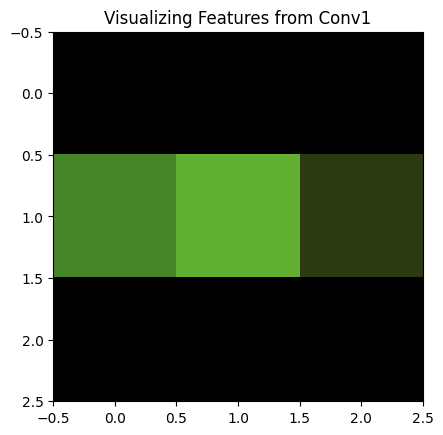

In [2]:
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt

# Load the MobileNetV2 model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Display model architecture
base_model.summary()

# Inspect layers and find the first layer with weights
layer_with_weights = None
for layer in base_model.layers:
    if layer.get_weights():
        layer_with_weights = layer
        break

if layer_with_weights:
    print(f"First layer with weights: {layer_with_weights.name}")
    weights = layer_with_weights.get_weights()[0]
    if weights.ndim == 4:  # Check if weights are compatible for visualization
        plt.imshow(weights[:, :, :, 0], cmap='viridis')
        plt.title(f'Visualizing Features from {layer_with_weights.name}')
        plt.show()
    else:
        print(f"Cannot visualize weights from layer {layer_with_weights.name}: incompatible dimensions.")
else:
    print("No layers with weights found in the model.")

In [3]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Freeze the base layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
output = Dense(10, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=output)

# Compile and train the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=10, batch_size=32)

# Print final validation accuracy
val_accuracy = history.history['val_accuracy'][-1]
print(f"Final Validation Accuracy: {val_accuracy:.2f}")

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 63s 46ms/step - accuracy: 0.2271 - loss: 2.1009 - val_accuracy: 0.3077 - val_loss: 1.9544
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 55s 44ms/step - accuracy: 0.2512 - loss: 2.0409 - val_accuracy: 0.3125 - val_loss: 1.9192
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 56s 45ms/step - accuracy: 0.2615 - loss: 2.0187 - val_accuracy: 0.3245 - val_loss: 1.9090
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 55s 44ms/step - accuracy: 0.2665 - loss: 2.0054 - val_accuracy: 0.3223 - val_loss: 1.9045
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 55s 44ms/step - accuracy: 0.2668 - loss: 1.9948 - val_accuracy: 0.3236 - val_loss: 1.8848
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 56s 44ms/step - accuracy: 0.2698 - loss: 1.9903 - val_accuracy: 0.3307 - val_loss: 1.8799
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 44ms/step - accuracy: 0.2734 - loss: 1.9847 - val_accuracy: 0.3236 - val_loss: 1.8742
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 55s 44ms/step - accuracy: 0.2728 -

In [4]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)
print(f"Test Accuracy: {test_accuracy:.2f}")

# Analyze feature maps from an intermediate layer
from tensorflow.keras.models import Model
intermediate_layer_model = Model(inputs=model.input, outputs=base_model.get_layer('block_1_expand_relu').output)
intermediate_output = intermediate_layer_model.predict(x_test[:5])

# Display feature map dimensions
print(f"Feature maps for the first test sample have shape: {intermediate_output[0].shape}")

313/313 - 11s - 34ms/step - accuracy: 0.3262 - loss: 1.8663
Test Accuracy: 0.33
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
Feature maps for the first test sample have shape: (16, 16, 96)


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

# Define a baseline model
baseline_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile and train the baseline model
baseline_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
baseline_history = baseline_model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=10, batch_size=32)

# Evaluate the baseline model
baseline_loss, baseline_accuracy = baseline_model.evaluate(x_test, y_test, verbose=2)
print(f"Baseline Model Test Accuracy: {baseline_accuracy:.2f}")

# Summarize comparison
print(f"Transfer Learning Test Accuracy: {test_accuracy:.2f}")
print(f"Baseline Model Test Accuracy: {baseline_accuracy:.2f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.4663 - loss: 1.4965 - val_accuracy: 0.5369 - val_loss: 1.3329
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.5816 - loss: 1.1944 - val_accuracy: 0.5823 - val_loss: 1.1856
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.6251 - loss: 1.0728 - val_accuracy: 0.6097 - val_loss: 1.1094
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.6557 - loss: 0.9842 - val_accuracy: 0.6102 - val_loss: 1.1232
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.6843 - loss: 0.9016 - val_accuracy: 0.6223 - val_loss: 1.1051
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 38s 31ms/step - accuracy: 0.7081 - loss: 0.8315 - val_accuracy: 0.6248 - val_loss: 1.1132
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.7348 - loss: 0.7641 - val_accuracy: 0.6338 - val_loss: 1.0737
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.7536 -

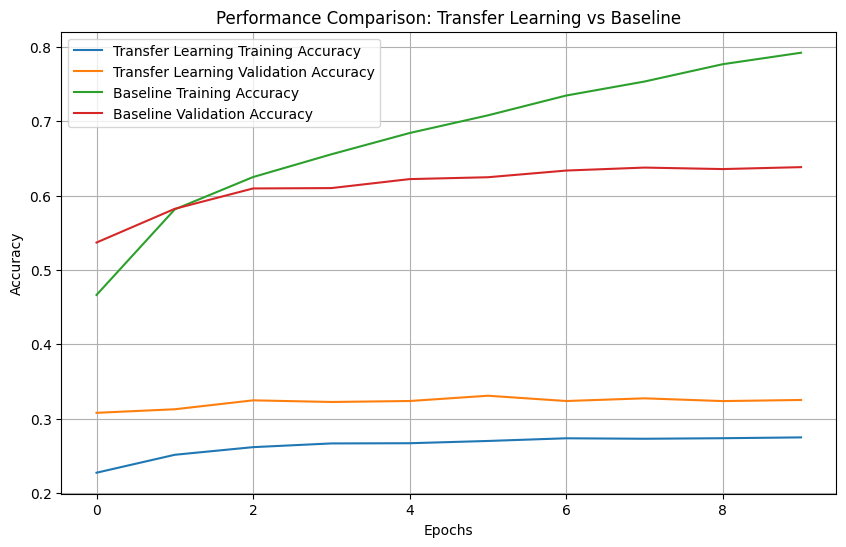

In [6]:
# Compare training and validation accuracy
plt.figure(figsize=(10, 6))

plt.plot(history.history['accuracy'], label='Transfer Learning Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Transfer Learning Validation Accuracy')
plt.plot(baseline_history.history['accuracy'], label='Baseline Training Accuracy')
plt.plot(baseline_history.history['val_accuracy'], label='Baseline Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Performance Comparison: Transfer Learning vs Baseline')
plt.legend()
plt.grid(True)

# Save the figure for GitHub
plt.savefig("transfer_learning_vs_baseline.png", dpi=300, bbox_inches="tight")

plt.show()

## Conclusion

From the comparison, it is evident that the baseline CNN model significantly outperforms the transfer learning model (MobileNetV2 with frozen layers) on the CIFAR-10 dataset. This could be attributed to several factors:

1.  **Input Image Size**: MobileNetV2 was originally trained on ImageNet with input images of size 224x224. Applying it directly to 32x32 CIFAR-10 images might lead to a loss of valuable features due to the downsampling performed by the base model's initial layers.
2.  **Feature Richness**: The CIFAR-10 dataset, while diverse, might not require the extremely complex and high-level features learned by MobileNetV2 on ImageNet. A simpler CNN architecture might be better suited to capture the relevant features for this particular dataset.
3.  **Frozen Layers**: Freezing the base model's layers prevents it from adapting to the CIFAR-10 specific features. If the features learned by MobileNetV2 on ImageNet are not sufficiently relevant or too abstract for CIFAR-10, fine-tuning or unfreezing some layers would likely be necessary to improve performance.

In this scenario, a custom-built simpler CNN proves more effective than a pre-trained, complex model when the target dataset (CIFAR-10) differs significantly in resolution and feature complexity from the original training dataset (ImageNet).